## Import

In [24]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Load the data

In [27]:
with open('logins.json', 'r') as file:
    data = json.load(file)

In [29]:
df = pd.DataFrame(data)

In [31]:
df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [33]:
# converting login_time to datetime dtype and set it as index
df["login_time"] = pd.to_datetime(df["login_time"])
df = df.set_index("login_time")
df

""
login_time
1970-01-01 20:13:18
1970-01-01 20:16:10
1970-01-01 20:16:37
1970-01-01 20:16:36
1970-01-01 20:26:21
...
1970-04-13 18:50:19
1970-04-13 18:43:56
1970-04-13 18:54:02


## Visualizations

In [35]:
#Aggregate login counts based on 15minute time intervals
login_counts = df.resample("15min").size()

login_time
1     7.333909
2     9.178943
3    11.331653
4    10.999186
dtype: float64


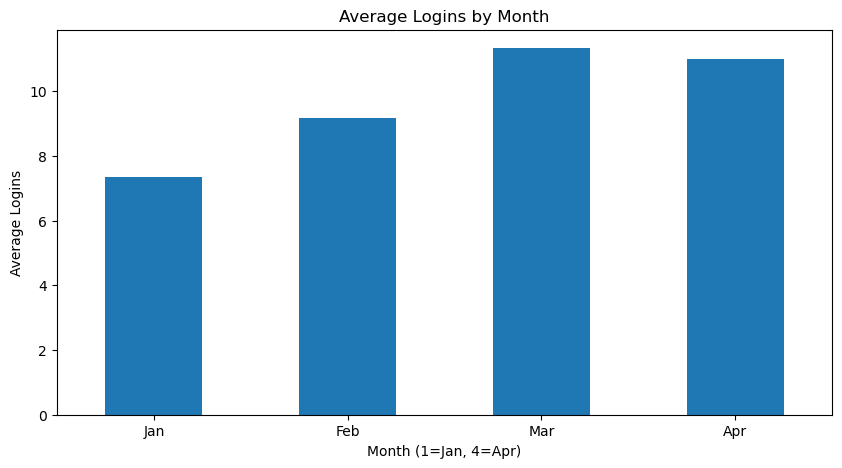

In [49]:
monthly_pattern = login_counts.groupby(login_counts.index.month).mean()   
plt.figure(figsize=(10, 5))
monthly_pattern.plot(kind='bar')
plt.title('Average Logins by Month')
plt.xlabel('Month (1=Jan, 4=Apr)')
plt.ylabel('Average Logins')
plt.xticks(range(4), ['Jan', 'Feb', 'Mar', 'Apr'], rotation=0)
print(monthly_pattern)

Monthly pattern shows March has the highest mean login counts. Aprils' login counts are not far behind as well.

In [40]:
daily_cycle = (
    login_counts
    .groupby(login_counts.index.time)
    .mean()
)

x_minutes = np.array([
    t.hour * 60 + t.minute for t in daily_cycle.index
])


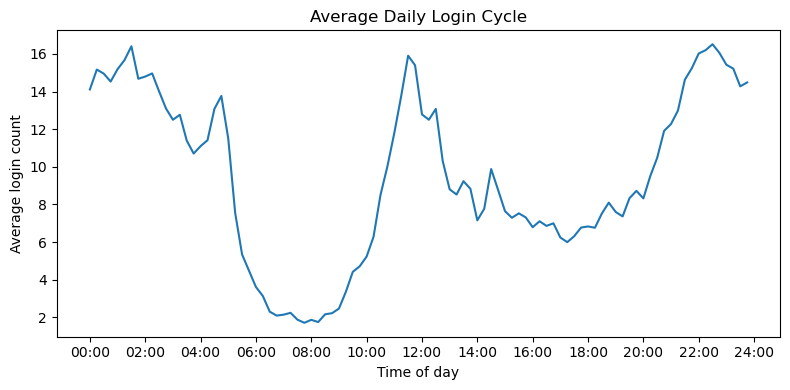

22:30:00    16.509804
01:30:00    16.401961
22:15:00    16.196078
22:45:00    16.049020
22:00:00    16.019608
              ...    
06:45:00     2.098039
07:30:00     1.882353
08:00:00     1.872549
08:15:00     1.754902
07:45:00     1.715686
Length: 96, dtype: float64


In [46]:
plt.figure(figsize=(8,4))
plt.plot(x_minutes, daily_cycle.values)

plt.xlabel("Time of day")
plt.ylabel("Average login count")
plt.title("Average Daily Login Cycle")

# Nice tick labels
plt.xticks(
    ticks=range(0, 1441, 120),
    labels=[f"{h:02d}:00" for h in range(0, 25, 2)]
)

plt.tight_layout()
plt.show()

print(daily_cycle.sort_values(ascending=False))

Daily login counts shows at 8 am in the morning is the least one and peaking around 11 am,1 am and 11 pm.

In [69]:
expected_index = pd.date_range(
    start=login_counts.index.min(),
    end=login_counts.index.max(),
    freq="15min"
)

missing = expected_index.difference(login_counts.index)
len(missing)


0

In [71]:
(login_counts == 0).sum()


407

In [73]:
login_counts[login_counts == 0].index[:10]


DatetimeIndex(['1970-01-01 21:30:00', '1970-01-02 04:15:00',
               '1970-01-02 06:15:00', '1970-01-02 18:00:00',
               '1970-01-03 08:45:00', '1970-01-03 10:00:00',
               '1970-01-03 10:15:00', '1970-01-04 07:15:00',
               '1970-01-05 06:30:00', '1970-01-05 07:00:00'],
              dtype='datetime64[ns]', name='login_time', freq=None)

In [75]:
login_counts.index.duplicated().sum()


0

<Axes: xlabel='login_time'>

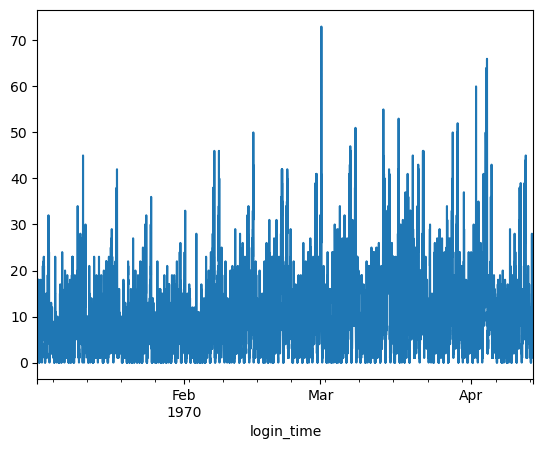

In [77]:
login_counts.plot()


In [134]:
login_counts.describe(percentiles=[0.95, 0.99])


count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
50%         7.000000
95%        26.000000
99%        38.000000
max        73.000000
dtype: float64

In [18]:
threshold = login_counts.mean() + 5 * login_counts.std()
outliers = login_counts[login_counts > threshold]
outliers

login_time
1970-03-01 04:30:00    73
1970-03-13 22:15:00    55
1970-03-17 01:30:00    53
1970-03-29 04:45:00    52
1970-04-01 23:30:00    60
1970-04-04 00:30:00    53
1970-04-04 01:00:00    54
1970-04-04 01:15:00    63
1970-04-04 01:30:00    64
1970-04-04 01:45:00    56
1970-04-04 04:45:00    59
1970-04-04 05:00:00    60
1970-04-04 05:15:00    59
1970-04-04 05:30:00    66
dtype: int64

In [83]:
misaligned = login_counts.index[
    (login_counts.index.minute % 15 != 0) |
    (login_counts.index.second != 0)
]
len(misaligned)


0

<Axes: xlabel='login_time'>

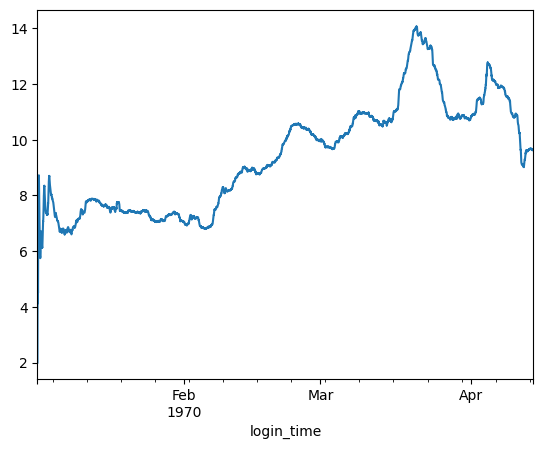

In [92]:
login_counts.rolling("7D").mean().plot()



<Axes: xlabel='login_time'>

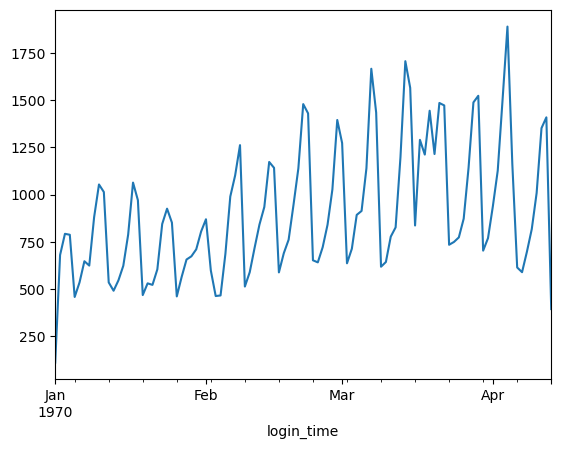

In [94]:
daily_totals = login_counts.resample("D").sum()
daily_totals.plot()


([<matplotlib.axis.XTick at 0x12fd62f00>,
 [Text(0, 0, 'Mon'),
  Text(1, 0, 'Tue'),
  Text(2, 0, 'Wed'),
  Text(3, 0, 'Thu'),
  Text(4, 0, 'Fri'),
  Text(5, 0, 'Sat'),
  Text(6, 0, 'Sun')])

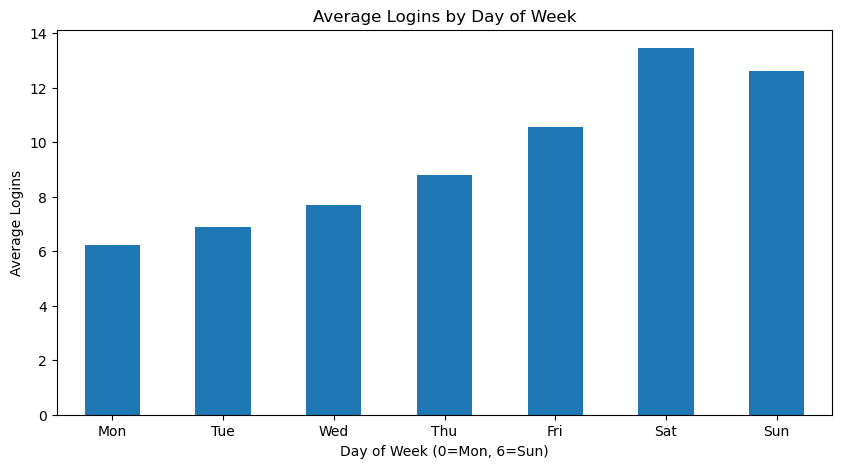

In [20]:
weekly_avg = login_counts.groupby(login_counts.index.weekday).mean()
plt.figure(figsize=(10, 5))
weekly_avg.plot(kind='bar')
plt.title('Average Logins by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average Logins')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)

In [98]:
dq_summary = {
    "total_intervals": len(login_counts),
    "missing_intervals": len(missing),
    "zero_intervals": int((login_counts == 0).sum()),
    "duplicate_timestamps": int(login_counts.index.duplicated().sum()),
    "max_value": float(login_counts.max()),
}
dq_summary


{'total_intervals': 9788,
 'missing_intervals': 0,
 'zero_intervals': 407,
 'duplicate_timestamps': 0,
 'max_value': 73.0}

In [149]:
df_hm = login_counts.to_frame(name="count")

df_hm["weekday"] = df_hm.index.weekday          # 0=Mon … 6=Sun
df_hm["time"] = df_hm.index.hour * 60 + df_hm.index.minute  # minutes since midnight


In [151]:
heatmap_data = (
    df_hm.groupby(["weekday", "time"])["count"]
      .mean()
      .unstack()
)


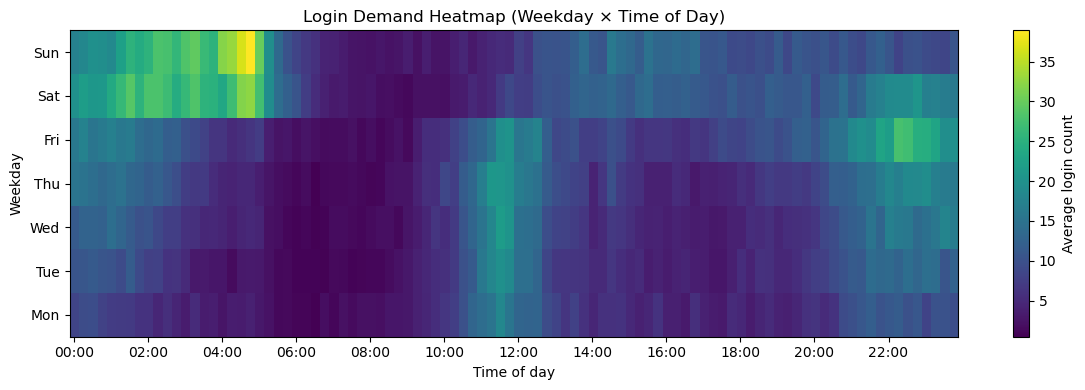

In [153]:
fig, ax = plt.subplots(figsize=(12,4))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    origin="lower"
)

# Axis labels
ax.set_xlabel("Time of day")
ax.set_ylabel("Weekday")

# Y-axis weekday labels
ax.set_yticks(range(7))
ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

# X-axis ticks every 2 hours
xticks = np.arange(0, 1440, 120)
ax.set_xticks(xticks / 15)  # divide by 15-min bins
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Average login count")

ax.set_title("Login Demand Heatmap (Weekday × Time of Day)")
plt.tight_layout()
plt.show()


## Demand characterization summary

1) Strong daily cycle (time-of-day)  
From the average daily cycle plot, the mean logins are:  
Highest late night / just after midnight, with top average 15-min slots around 00:15–01:00 and also around 23:15.  
Lowest in the morning, with the weakest average 15-min slots around 07:30–09:00.  
This is the clearest “daily seasonality” signal in the dataset.  

2) Weekday vs weekend effect  
Daily totals show a clear uplift on weekends:  
Saturday has the highest average daily volume, then Sunday, then Friday, with Monday lowest.
This suggests demand is not only daily-cyclical, but also weekly-seasonal.

3) Spiky bursts / peaks  
Peak 15-minute intervals reach up to 73 logins in a single 15-minute bin, and the top spikes often occur late night / early morning (see the top of the time series and the heatmap bands).  